<a href="https://colab.research.google.com/github/databyhuseyn/sideProjects/blob/main/RL_Trading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gym gym-anytrading stable-baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.2/172.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-c

In [ ]:
!pip install finta

In [ ]:
from finta import TA
import gym
import gym_anytrading
from gym_anytrading.envs import StocksEnv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import PPO


In [ ]:
df = pd.read_csv('/content/Download Data - STOCK_US_XNAS_AMZN.csv')

In [ ]:
df.head()

,Date,Open,High,Low,Close,Volume
0,03/27/2025,200.89,203.79,199.28,201.36,"27,317,660"
1,03/26/2025,205.84,206.01,199.93,201.13,"32,990,969"
2,03/25/2025,203.60,206.21,203.22,205.71,"31,171,160"
3,03/24/2025,200.00,203.64,199.95,203.26,"41,625,367"
4,03/21/2025,192.90,196.99,192.52,196.21,"60,056,922"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    251 non-null    object 
 1   Open    251 non-null    float64
 2   High    251 non-null    float64
 3   Low     251 non-null    float64
 4   Close   251 non-null    float64
 5   Volume  251 non-null    object 
dtypes: float64(4), object(2)
memory usage: 11.9+ KB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    251 non-null    datetime64[ns]
 1   Open    251 non-null    float64       
 2   High    251 non-null    float64       
 3   Low     251 non-null    float64       
 4   Close   251 non-null    float64       
 5   Volume  251 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 11.9+ KB


In [ ]:
# df['Open'] = pd.to_numeric(df['Open'].str.replace(',',''), downcast='float')
# df['High'] = pd.to_numeric(df['High'].str.replace(',',''), downcast='float')
# df['Low'] = pd.to_numeric(df['Low'].str.replace(',',''), downcast='float')
# df['Close'] = pd.to_numeric(df['Close'].str.replace(',',''), downcast='float')
df['Volume'] = pd.to_numeric(df['Volume'].str.replace(',',''), downcast='float')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    251 non-null    datetime64[ns]
 1   Open    251 non-null    float64       
 2   High    251 non-null    float64       
 3   Low     251 non-null    float64       
 4   Close   251 non-null    float64       
 5   Volume  251 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 11.9 KB


In [ ]:
df.sort_values(by='Date', inplace=True)

In [ ]:
df.set_index('Date', inplace=True)
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2024-03-27,179.88,180.00,177.31,179.83,33272551.0
2024-03-28,180.17,181.70,179.26,180.38,38051594.0
2024-04-01,180.79,183.00,179.95,180.97,29174520.0
2024-04-02,179.07,180.79,178.38,180.69,32611551.0
2024-04-03,179.90,182.87,179.80,182.41,31046641.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2024-03-27 to 2025-03-27
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    251 non-null    float64
 1   High    251 non-null    float64
 2   Low     251 non-null    float64
 3   Close   251 non-null    float64
 4   Volume  251 non-null    float64
dtypes: float64(5)
memory usage: 11.8 KB


In [ ]:
df['VWAP'] = TA.VWAP(df)
df['SMA'] = TA.SMA(df,12)
df['EMA'] = TA.EMA(df, 12)
df['WMA'] = TA.WMA(df, 12)
# df['MACD_open'] = TA.MACD(df['Open'])
# df['MACD_high'] = TA.MACD(df['High'])
# df['MACD_low'] = TA.MACD(df['Low'])
# df['MACD_close'] = TA.MACD(df['Close'])
# df['MACD_vol'] = TA.MACD(df['Volume'])
# df['BBANDS_open'] = TA.BBANDS(df['Open'])
# df['BBANDS_high'] = TA.BBANDS(df['High'])
# df['BBANDS_low'] = TA.BBANDS(df['Low'])
# df['BBANDS_close'] = TA.BBANDS(df['Close'])
# df['BBANDS_vol'] = TA.BBANDS(df['Volume'])
# df['KC_open'] = TA.KC(df['Open'])
# df['KC_high'] = TA.KC(df['High'])
# df['KC_low'] = TA.KC(df['Low'])
# df['KC_close'] = TA.KC(df['Close'])
# df['KC_vol'] = TA.KC(df['Volume'])
df['RSI'] = TA.RSI(df)
df['OBV'] = TA.OBV(df)
df['STOCH'] = TA.STOCH(df)
df['CCI'] = TA.CCI(df)
df['MOM'] = TA.MOM(df)
df['SQZMI'] = TA.SQZMI(df)
df['ATR'] = TA.ATR(df)
df['ADL'] = TA.ADL(df)
df['MFI'] = TA.MFI(df)


In [ ]:
df.fillna(0, inplace=True)

In [ ]:
df.isna().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
VWAP,0
SMA,0
EMA,0
WMA,0
RSI,0


In [ ]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'VWAP', 'SMA', 'EMA', 'WMA',
       'RSI', 'OBV', 'STOCH', 'CCI', 'MOM', 'SQZMI', 'ATR', 'ADL', 'MFI'],
      dtype='object')

In [ ]:
def add_signals(env):
  start = env.frame_bound[0] - env.window_size
  end = env.frame_bound[1]
  prices = env.df.loc[:, 'Low'].to_numpy()[start:end]
  signal_features = env.df.loc[:, ['Low', 'Volume', 'SMA', 'EMA', 'WMA', 'RSI',
       'VWAP', 'OBV', 'STOCH', 'CCI', 'MOM', 'SQZMI', 'ATR', 'ADL', 'MFI']].to_numpy()[start:end]

  signal_features = signal_features.astype(np.float32)
  return prices, signal_features

In [ ]:
class MyCustomEnv(StocksEnv):
  _process_data = add_signals

env2 = MyCustomEnv(df=df, window_size=12, frame_bound=(12, len(df)))

In [ ]:
env2.prices

array([177.31, 179.26, 179.95, 178.38, 179.8 , 180.  , 181.97, 184.81,
       184.2 , 182.67, 185.51, 185.08, 183.  , 182.26, 179.82, 178.65,
       173.44, 174.56, 175.98, 176.18, 166.32, 176.13, 179.39, 174.8 ,
       176.56, 179.91, 185.42, 184.8 , 187.31, 186.39, 187.44, 186.93,
       185.36, 183.45, 182.73, 183.46, 183.35, 183.28, 180.75, 181.97,
       180.08, 180.3 , 179.49, 181.55, 178.36, 173.87, 175.92, 176.44,
       178.75, 181.49, 183.36, 183.79, 184.54, 185.43, 182.67, 182.23,
       181.22, 181.43, 182.72, 185.86, 185.33, 185.42, 186.26, 194.2 ,
       192.5 , 192.82, 195.93, 196.76, 198.17, 197.96, 199.05, 197.69,
       192.86, 193.83, 190.83, 192.24, 185.99, 181.45, 180.11, 182.48,
       183.56, 180.41, 176.8 , 180.24, 182.38, 179.38, 184.46, 181.87,
       160.55, 151.61, 158.54, 161.43, 162.55, 165.85, 166.11, 167.1 ,
       168.86, 173.99, 176.26, 176.16, 177.43, 178.89, 175.68, 175.24,
       174.3 , 172.25, 168.92, 170.81, 172.6 , 175.26, 172.54, 175.  ,
      

In [ ]:
env2.signal_features

array([[1.7731000e+02, 3.3272552e+07, 0.0000000e+00, ..., 0.0000000e+00,
        2.9067098e+07, 0.0000000e+00],
       [1.7925999e+02, 3.8051592e+07, 0.0000000e+00, ..., 0.0000000e+00,
        2.5948116e+07, 0.0000000e+00],
       [1.7995000e+02, 2.9174520e+07, 0.0000000e+00, ..., 0.0000000e+00,
        1.6287045e+07, 0.0000000e+00],
       ...,
       [2.0322000e+02, 3.1171160e+07, 1.9717416e+02, ..., 6.4285712e+00,
        7.6859802e+08, 4.4553993e+01],
       [1.9992999e+02, 3.2990968e+07, 1.9772333e+02, ..., 6.1442857e+00,
        7.4862982e+08, 4.5763641e+01],
       [1.9928000e+02, 2.7317660e+07, 1.9812083e+02, ..., 5.7707143e+00,
        7.4650982e+08, 4.8221504e+01]], dtype=float32)

In [ ]:
df.head()

,Open,High,Low,Close,Volume,VWAP,SMA,EMA,WMA,RSI,OBV,STOCH,CCI,MOM,SQZMI,ATR,ADL,MFI
Date,,,,,,,,,,,,,,,,,,
2024-03-27,179.88,180.00,177.31,179.83,33272551.0,179.046667,0.0,179.830000,0.0,0.000000,0.0,0.0,0.000000,0.0,False,0.0,2.906710e+07,0.0
2024-03-28,180.17,181.70,179.26,180.38,38051594.0,179.793570,0.0,180.127917,0.0,100.000000,38051594.0,0.0,66.666667,0.0,False,0.0,2.594812e+07,0.0
2024-04-01,180.79,183.00,179.95,180.97,29174520.0,180.232818,0.0,180.456582,0.0,100.000000,67226114.0,0.0,85.245902,0.0,False,0.0,1.628704e+07,0.0
2024-04-02,179.07,180.79,178.38,180.69,32611551.0,180.164345,0.0,180.530263,0.0,78.496140,34614563.0,0.0,-22.760291,0.0,False,0.0,4.619224e+07,0.0
2024-04-03,179.90,182.87,179.80,182.41,31046641.0,180.453520,0.0,181.040981,0.0,91.123509,65661204.0,0.0,99.274406,0.0,False,0.0,6.793500e+07,0.0


In [ ]:
env_maker = lambda: env2
env = DummyVecEnv([env_maker])

In [ ]:
model = PPO('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=30000)

Using cuda device


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 696  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 551          |
|    iterations           | 2            |
|    time_elapsed         | 7            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0067082047 |
|    clip_fraction        | 0.0271       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.688       |
|    explained_variance   | -0.0288      |
|    learning_rate        | 0.0003       |
|    loss                 | 17.6         |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00551     |
|    value_loss           | 48           |
------------------------------------------
----------------

# Eval

In [ ]:
# env = MyCustomEnv(df=df, window_size=12, frame_bound=(12,50))
obs, info = env2.reset()
while True:
    # obs = obs[np.newaxis, ...] # Remove this line or modify it
    obs = obs.reshape(env.num_envs, *env2.shape) # Reshape the observation to match the expected shape
    action, _states = model.predict(obs)
    obs, rewards, done, info = env.step(action)
    if done:
        print("info", info)
        break

AttributeError: 'MyCustomEnv' object has no attribute 'num_envs'

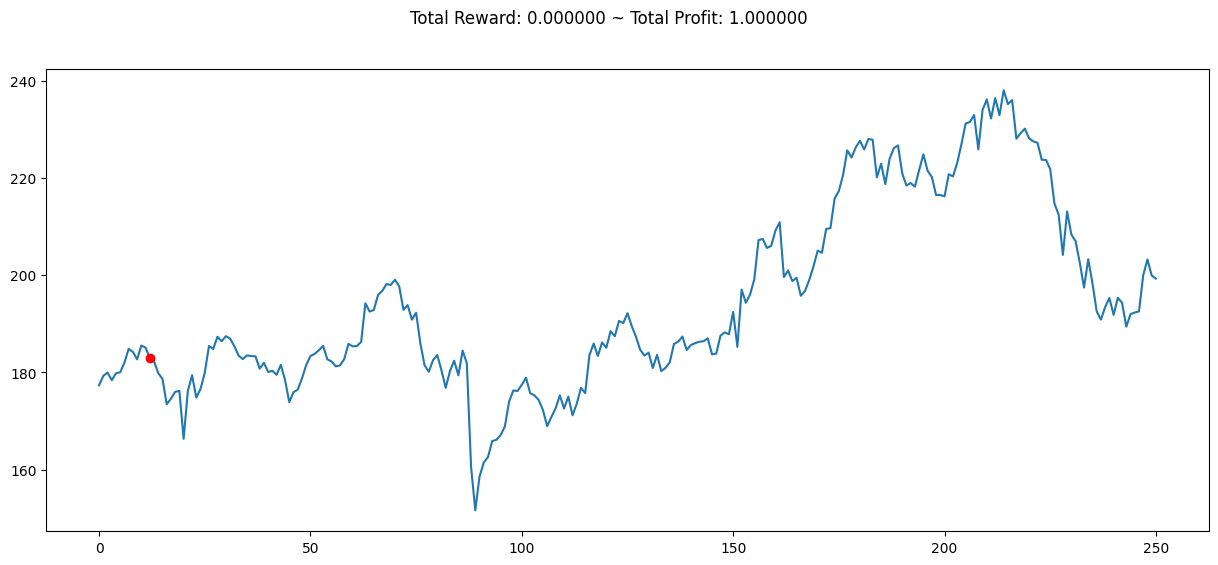

In [ ]:
plt.figure(figsize=(15,6))
plt.cla()
env2.render_all()
plt.show()